# E-commerce Sales & Customer Analysis

## Project Overview

This project analyzes e-commerce sales data to identify trends in revenue,
profitability, customer behavior, product performance, and regional sales.

### Objectives

- Analyze overall sales and profitability
- Identify top-performing products and categories
- Analyze monthly sales trends
- Identify top customers
- Compare regional performance
- Analyze the relationship between discounts and profit
- Generate actionable business recommendations

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## This data is for the year 2025

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt      #for charts
import seaborn as sns

In [32]:
pd.set_option("display.max_columns", None)      #This tells Pandas to display all columns when we inspect the dataset.

## 1. Load the Dataset

The dataset contains e-commerce transaction records for the year 2025.

In [25]:
df = pd.read_csv("data/ecommerce_sales_raw.csv")

In [56]:
df.head()    #display the first five records

,order_id,order_date,customer_id,customer_name,gender,age,city,state,region,product_id,product_name,category,quantity,unit_price,discount,sales,cost,profit
0,O00001,2025-06-25,C0481,Isha Mehta,Female,45,Bengaluru,Karnataka,South,P010,Yoga Mat,Sports,2,1200,0.05,2280.0,1300,980.0
1,O00002,2025-03-08,C0060,Aditi Sharma,Female,21,Mumbai,Maharashtra,West,P004,Smart Watch,Electronics,1,6500,0.15,5525.0,4000,1525.0
2,O00003,2025-03-07,C0025,Vikram Shah,Male,41,Chennai,Tamil Nadu,South,P020,Notebook Set,Stationery,2,500,0.10,900.0,440,460.0
3,O00004,2025-03-24,C0496,Sneha Singh,Male,45,Lucknow,Uttar Pradesh,North,P012,Air Fryer,Home Appliances,3,7500,0.15,19125.0,14400,4725.0
4,O00005,2025-12-16,C0211,Sneha Reddy,Female,57,Ahmedabad,Gujarat,West,P003,Headphones,Electronics,1,2500,0.05,2375.0,1400,975.0


In [27]:
df.shape

(5000, 18)

In [28]:
df.info()            #displays data types

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       5000 non-null   str    
 1   order_date     5000 non-null   str    
 2   customer_id    5000 non-null   str    
 3   customer_name  4995 non-null   str    
 4   gender         5000 non-null   str    
 5   age            5000 non-null   int64  
 6   city           4992 non-null   str    
 7   state          5000 non-null   str    
 8   region         5000 non-null   str    
 9   product_id     5000 non-null   str    
 10  product_name   5000 non-null   str    
 11  category       5000 non-null   str    
 12  quantity       5000 non-null   int64  
 13  unit_price     5000 non-null   int64  
 14  discount       4994 non-null   float64
 15  sales          5000 non-null   float64
 16  cost           5000 non-null   int64  
 17  profit         5000 non-null   float64
dtypes: float64(3), int6

In [57]:
df.isnull().sum()       #missing values in a few columns

order_id         0
order_date       0
customer_id      0
customer_name    5
gender           0
age              0
city             8
state            0
region           0
product_id       0
product_name     0
category         0
quantity         0
unit_price       0
discount         6
sales            0
cost             0
profit           0
dtype: int64

In [35]:
df_clean = df.copy()

In [36]:
df_clean["customer_name"] = df_clean["customer_name"].fillna("Unknown Customer")

In [37]:
df_clean["city"] = df_clean["city"].fillna("Unknown")

In [38]:
df_clean["discount"] = df_clean["discount"].fillna(0)

In [40]:
df_clean.isnull().sum()

order_id         0
order_date       0
customer_id      0
customer_name    0
gender           0
age              0
city             0
state            0
region           0
product_id       0
product_name     0
category         0
quantity         0
unit_price       0
discount         0
sales            0
cost             0
profit           0
dtype: int64

In [42]:
df_clean["order_date"] = pd.to_datetime(df_clean["order_date"])       #convert the date format using pandas

In [44]:
df_clean.dtypes

order_id                    str
order_date       datetime64[us]
customer_id                 str
customer_name               str
gender                      str
age                       int64
city                        str
state                       str
region                      str
product_id                  str
product_name                str
category                    str
quantity                  int64
unit_price                int64
discount                float64
sales                   float64
cost                      int64
profit                  float64
dtype: object

In [49]:
df_clean.duplicated().sum()         #check duplicates

np.int64(0)

In [50]:
df_clean["order_id"].duplicated().sum() 

np.int64(0)

In [53]:
df_clean.describe()           #basic statistical analysis

,order_date,age,quantity,unit_price,discount,sales,cost,profit
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2025-06-29 10:42:48.960000,39.470800,1.852600,8349.800000,0.105910,13796.639000,10958.640000,2837.999000
min,2025-01-01 00:00:00,18.000000,1.000000,500.000000,0.000000,375.000000,220.000000,-2250.000000
25%,2025-03-29 00:00:00,29.000000,1.000000,1500.000000,0.050000,2125.000000,1300.000000,765.000000
50%,2025-06-28 00:00:00,40.000000,2.000000,2500.000000,0.100000,4500.000000,2800.000000,1500.000000
75%,2025-09-28 00:00:00,51.000000,2.000000,7000.000000,0.150000,12150.000000,8500.000000,3100.000000
max,2025-12-31 00:00:00,60.000000,5.000000,55000.000000,0.250000,275000.000000,210000.000000,65000.000000
std,NaN,12.313776,1.036286,13398.848525,0.066667,26709.478135,22735.107209,4512.551146


## 3. Overall Business Performance

In [58]:
total_revenue = df_clean["sales"].sum()        #total revenue

total_revenue

np.float64(68983195.0)

In [60]:
total_profit = df_clean["profit"].sum()       #total profit

total_profit

np.float64(14189995.0)

In [78]:
total_orders = df_clean["order_id"].nunique()      #total unique orders

total_orders

5000

In [79]:
total_quantity = df_clean["quantity"].sum()       #total quantities sold

total_quantity

np.int64(9263)

In [66]:
average_order_value = total_revenue/total_orders

average_order_value

np.float64(13796.639)

In [68]:
profit_margin = (total_profit/total_revenue) * 100

profit_margin

np.float64(20.570220036923487)

## 4. Exploratory Data Analysis

In this section, we analyze sales trends, product performance, customer behavior,
regional performance, and profitability.

In [74]:
df_clean["month"] = df_clean["order_date"].dt.to_period("M").astype(str)       #create month column

df_clean.head()

,order_id,order_date,customer_id,customer_name,gender,age,city,state,region,product_id,product_name,category,quantity,unit_price,discount,sales,cost,profit,month
0,O00001,2025-06-25,C0481,Isha Mehta,Female,45,Bengaluru,Karnataka,South,P010,Yoga Mat,Sports,2,1200,0.05,2280.0,1300,980.0,2025-06
1,O00002,2025-03-08,C0060,Aditi Sharma,Female,21,Mumbai,Maharashtra,West,P004,Smart Watch,Electronics,1,6500,0.15,5525.0,4000,1525.0,2025-03
2,O00003,2025-03-07,C0025,Vikram Shah,Male,41,Chennai,Tamil Nadu,South,P020,Notebook Set,Stationery,2,500,0.10,900.0,440,460.0,2025-03
3,O00004,2025-03-24,C0496,Sneha Singh,Male,45,Lucknow,Uttar Pradesh,North,P012,Air Fryer,Home Appliances,3,7500,0.15,19125.0,14400,4725.0,2025-03
4,O00005,2025-12-16,C0211,Sneha Reddy,Female,57,Ahmedabad,Gujarat,West,P003,Headphones,Electronics,1,2500,0.05,2375.0,1400,975.0,2025-12


In [75]:
monthly_sales = df_clean.groupby("month")["sales"].sum().reset_index()           #calculate monthly sales

monthly_sales

,month,sales
0,2025-01,5688410.0
1,2025-02,6458550.0
2,2025-03,5447700.0
3,2025-04,5698790.0
4,2025-05,5069950.0
5,2025-06,5669580.0
6,2025-07,6688690.0
7,2025-08,5665015.0
8,2025-09,4784930.0
9,2025-10,5914280.0


In [77]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

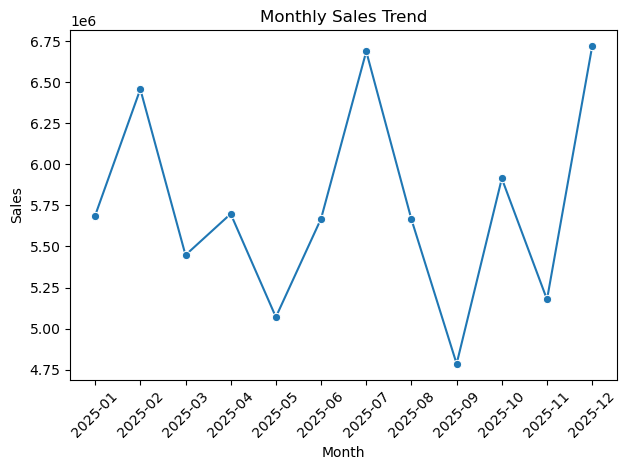

In [80]:
sns.lineplot(
    data=monthly_sales,
    x="month",
    y="sales",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [81]:
monthly_profit = df_clean.groupby("month")["profit"].sum().reset_index()

monthly_profit

,month,profit
0,2025-01,1184980.0
1,2025-02,1307360.0
2,2025-03,1150240.0
3,2025-04,1185430.0
4,2025-05,1099740.0
5,2025-06,1109860.0
6,2025-07,1312420.0
7,2025-08,1195615.0
8,2025-09,969240.0
9,2025-10,1167150.0


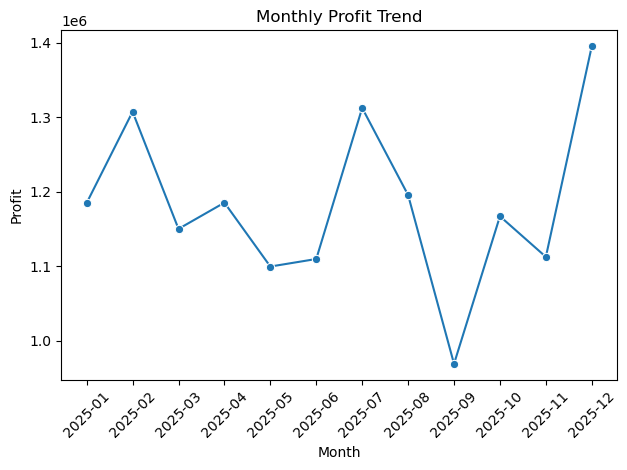

In [84]:
sns.lineplot(
    data=monthly_profit,
    x="month",
    y="profit",
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
category_sales = (
    df_clean.groupby("category")["sales"].sum().sort_values(ascending=False)
)

category_sales

category
Electronics        45793350.0
Furniture           9159225.0
Home Appliances     5528315.0
Fashion             3026170.0
Sports              2784810.0
Home Decor          1561350.0
Accessories          858000.0
Stationery           271975.0
Name: sales, dtype: float64

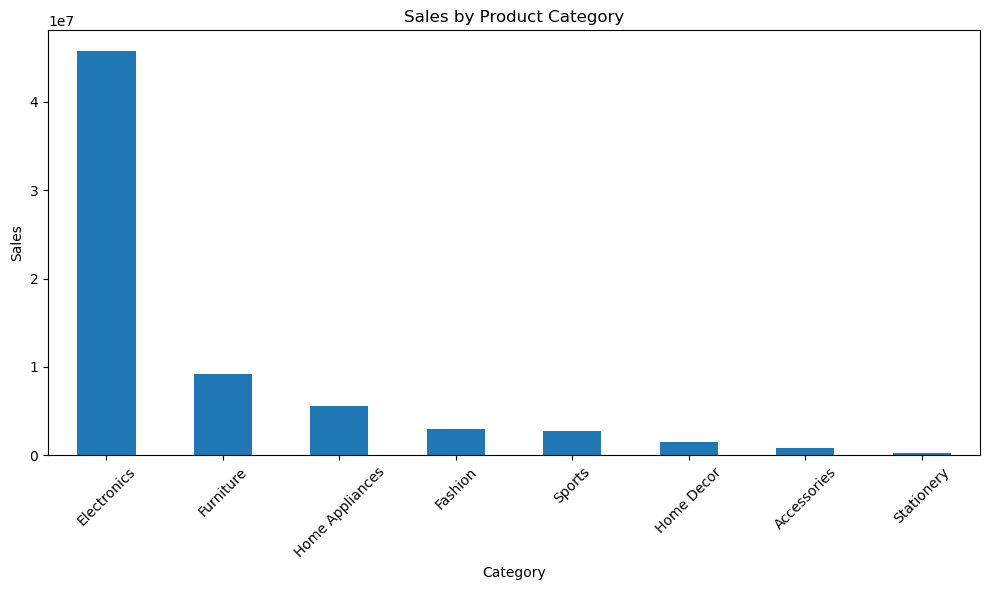

In [91]:
plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [92]:
category_profit = (
    df_clean.groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

category
Electronics        7449350.0
Furniture          1961625.0
Home Appliances    1596115.0
Fashion            1087670.0
Sports              973560.0
Home Decor          648000.0
Accessories         334800.0
Stationery          138875.0
Name: profit, dtype: float64

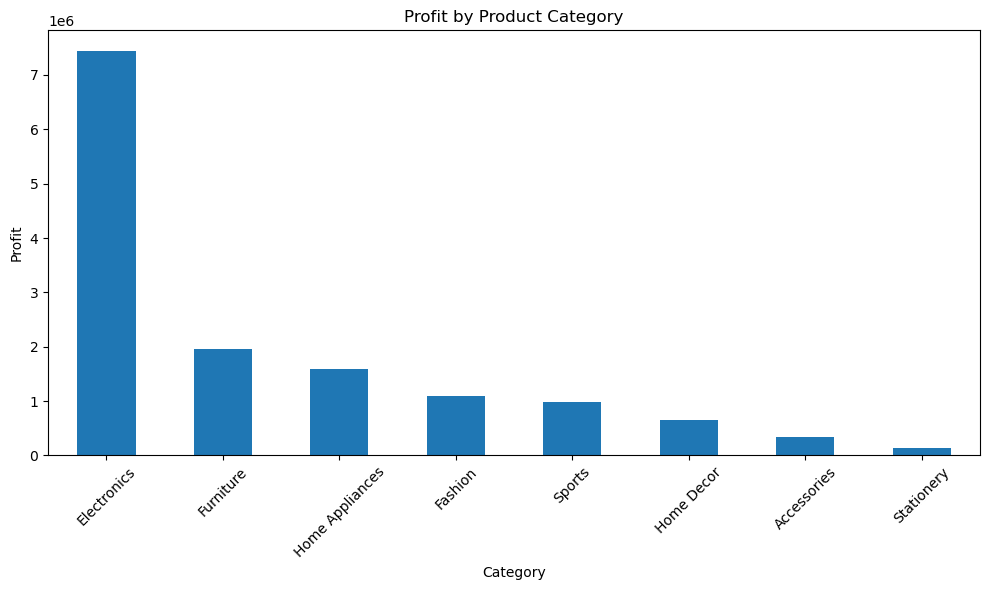

In [93]:
plt.figure(figsize=(10, 6))

category_profit.plot(kind="bar")

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [94]:
top_products = df_clean.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10)

top_products

product_name
Laptop           25960000.0
Smartphone       15827000.0
Desk              4250400.0
Office Chair      3088475.0
Smart Watch       2496975.0
Air Fryer         2300625.0
Running Shoes     2040750.0
Bookshelf         1820350.0
Coffee Maker      1656050.0
Mixer Grinder     1571640.0
Name: sales, dtype: float64

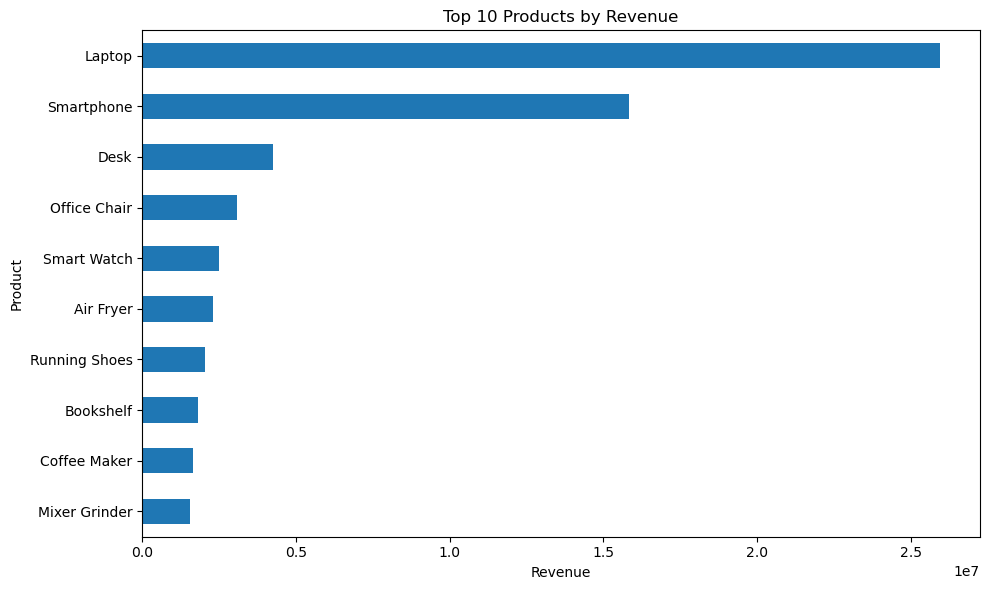

In [96]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')    #bar graph horizontally
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [97]:
top_profit_products = (
    df_clean.groupby("product_name")["profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit_products

product_name
Laptop           3826000.0
Smartphone       2282000.0
Desk              884400.0
Smart Watch       776975.0
Running Shoes     679950.0
Air Fryer         663825.0
Office Chair      658475.0
Headphones        564375.0
Coffee Maker      500050.0
Jacket            454725.0
Name: profit, dtype: float64

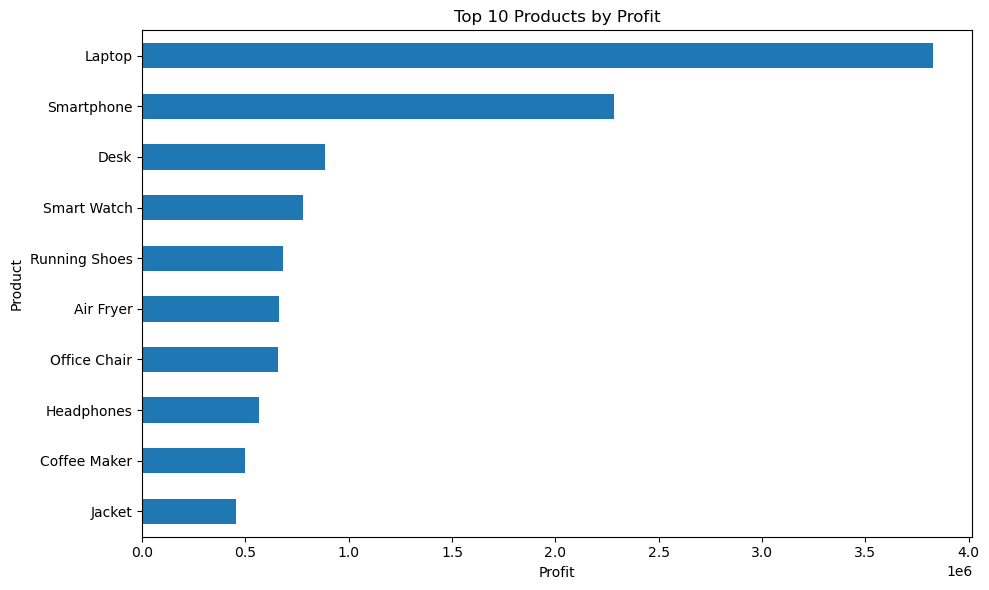

In [98]:
plt.figure(figsize=(10, 6))

top_profit_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [99]:
regional_sales = (
    df_clean.groupby("region")["sales"]
    .sum()
    .sort_values(ascending=False)
)

regional_sales

region
South    23395825.0
West     17547265.0
North    16133660.0
East     11906445.0
Name: sales, dtype: float64

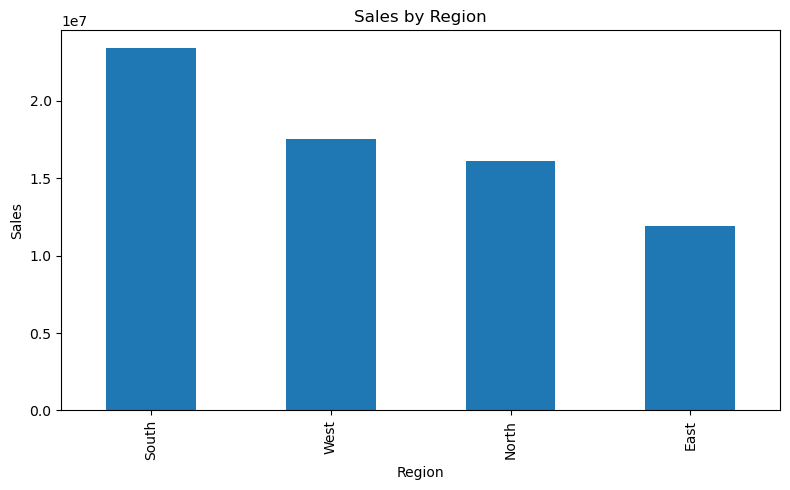

In [101]:
plt.figure(figsize=(8, 5))

regional_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [102]:
regional_profit = (
    df_clean.groupby("region")["profit"]
    .sum()
    .sort_values(ascending=False)
)

regional_profit

region
South    4877725.0
West     3577435.0
North    3297030.0
East     2437805.0
Name: profit, dtype: float64

In [109]:
top_customers = (                         #top 10 customers for sales
    df_clean.groupby(["customer_id", "customer_name"])["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)       
)

top_customers

customer_id  customer_name
C0183        Kavya Gupta      531055.0
C0146        Simran Iyer      473920.0
C0872        Nikhil Shah      431000.0
C0220        Varun Sharma     416215.0
C0182        Meera Desai      413615.0
C0013        Sneha Desai      377220.0
C0090        Simran Nair      361020.0
C0633        Nikhil Patel     350500.0
C0547        Rohan Verma      324110.0
C0900        Arjun Sharma     305000.0
Name: sales, dtype: float64

In [107]:
customer_orders = (                     #count orders per customers
    df_clean.groupby("customer_id")["order_id"]
    .nunique()
)

In [108]:
repeat_customers = (customer_orders > 1).sum()               #calc repeat customers

repeat_customers

np.int64(925)

In [110]:
total_customers = df_clean["customer_id"].nunique()           #total customers

total_customers

990

In [112]:
repeat_customer_percentage = repeat_customers/total_customers*100

repeat_customer_percentage

np.float64(93.43434343434343)

In [113]:
df_clean["discount_percentage"] = df_clean["discount"] * 100

In [117]:
discount_analysis = df_clean.groupby("discount_percentage").agg(               #how much profit on each discount rate
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        average_profit=("profit", "mean"),
        order_count=("order_id", "count")
    ).reset_index()

discount_analysis

,discount_percentage,total_sales,total_profit,average_profit,order_count
0,0.0,9291960.0,2663510.0,4446.594324,599
1,5.0,15630255.0,3919275.0,3652.632805,1073
2,10.0,22298490.0,4630490.0,3052.399473,1517
3,15.0,12762920.0,2130450.0,2084.589041,1022
4,20.0,6119120.0,702400.0,1332.827324,527
5,25.0,2880450.0,143870.0,549.122137,262


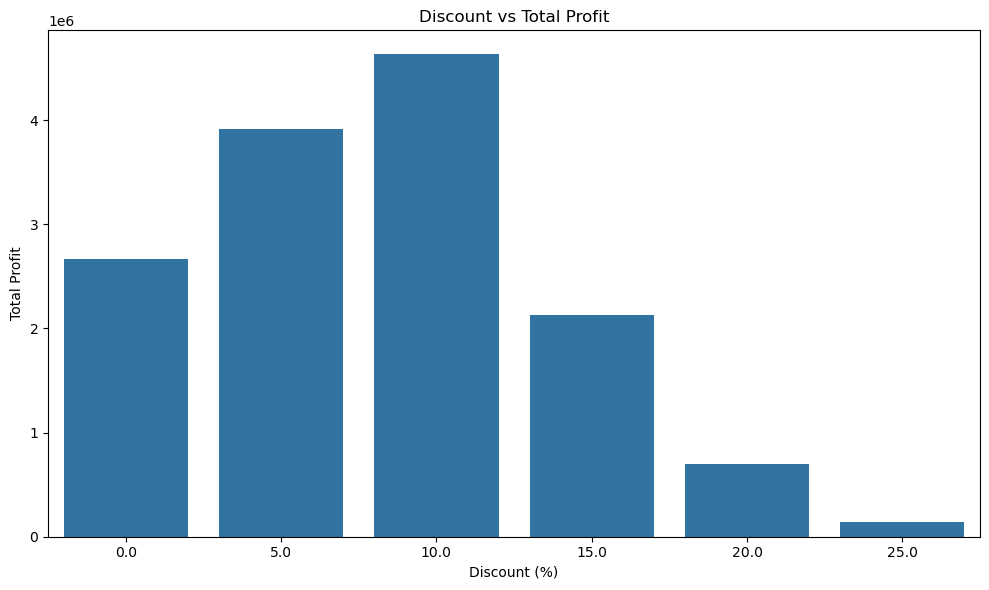

In [118]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=discount_analysis,
    x="discount_percentage",
    y="total_profit"
)

plt.title("Discount vs Total Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.show()

In [119]:
product_analysis = (
    df_clean.groupby("product_name")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        quantity_sold=("quantity", "sum")
    )
    .reset_index()
)

In [123]:
product_analysis["profit_margin"] = (             #calc profit percentage
    product_analysis["total_profit"] /
    product_analysis["total_sales"]
) * 100

In [122]:
product_analysis.sort_values(               #sort by the total sales
    "total_sales",
    ascending=False
).head(10)

,product_name,total_sales,total_profit,quantity_sold,profit_margin
9,Laptop,25960000.0,3826000.0,527,14.738059
15,Smartphone,15827000.0,2282000.0,630,14.418399
5,Desk,4250400.0,884400.0,396,20.807453
12,Office Chair,3088475.0,658475.0,405,21.320393
14,Smart Watch,2496975.0,776975.0,430,31.116651
0,Air Fryer,2300625.0,663825.0,341,28.854116
13,Running Shoes,2040750.0,679950.0,504,33.318633
2,Bookshelf,1820350.0,418750.0,292,23.003818
3,Coffee Maker,1656050.0,500050.0,340,30.195344
10,Mixer Grinder,1571640.0,432240.0,422,27.502481


In [125]:
product_analysis.sort_values(         #high sales but low margins
    "profit_margin"
).head(10)

,product_name,total_sales,total_profit,quantity_sold,profit_margin
15,Smartphone,15827000.0,2282000.0,630,14.418399
9,Laptop,25960000.0,3826000.0,527,14.738059
5,Desk,4250400.0,884400.0,396,20.807453
12,Office Chair,3088475.0,658475.0,405,21.320393
2,Bookshelf,1820350.0,418750.0,292,23.003818
10,Mixer Grinder,1571640.0,432240.0,422,27.502481
0,Air Fryer,2300625.0,663825.0,341,28.854116
3,Coffee Maker,1656050.0,500050.0,340,30.195344
14,Smart Watch,2496975.0,776975.0,430,31.116651
13,Running Shoes,2040750.0,679950.0,504,33.318633


In [127]:
df_clean.to_csv(
    "data/ecommerce_sales_cleaned.csv",
    index=False
)

In [129]:
total_revenue = df_clean["sales"].sum()
total_profit = df_clean["profit"].sum()
total_orders = df_clean["order_id"].nunique()
total_customers = df_clean["customer_id"].nunique()
total_quantity = df_clean["quantity"].sum()

average_order_value = total_revenue / total_orders
profit_margin = (total_profit / total_revenue) * 100

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Total Quantity Sold",
        "Average Order Value",
        "Profit Margin"
    ],
    "Value": [
        total_revenue,
        total_profit,
        total_orders,
        total_customers,
        total_quantity,
        average_order_value,
        profit_margin
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,6.898320e+07
1,Total Profit,1.419000e+07
2,Total Orders,5.000000e+03
3,Total Customers,9.900000e+02
4,Total Quantity Sold,9.263000e+03
5,Average Order Value,1.379664e+04
6,Profit Margin,2.057022e+01


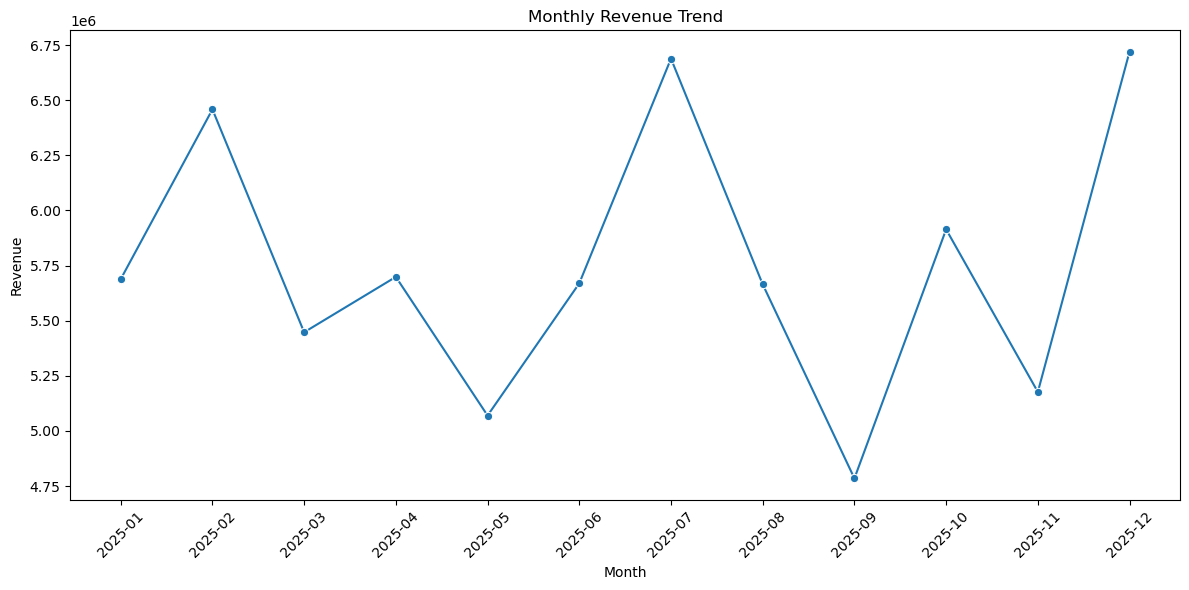

In [130]:
monthly_sales = (
    df_clean.groupby("month", as_index=False)["sales"]
    .sum()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="sales",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [132]:
best_sales_month = monthly_sales.loc[
    monthly_sales["sales"].idxmax()
]

best_sales_month

month      2025-12
sales    6720285.0
Name: 11, dtype: object

In [133]:
lowest_sales_month = monthly_sales.loc[
    monthly_sales["sales"].idxmin()
]

lowest_sales_month

month      2025-09
sales    4784930.0
Name: 8, dtype: object

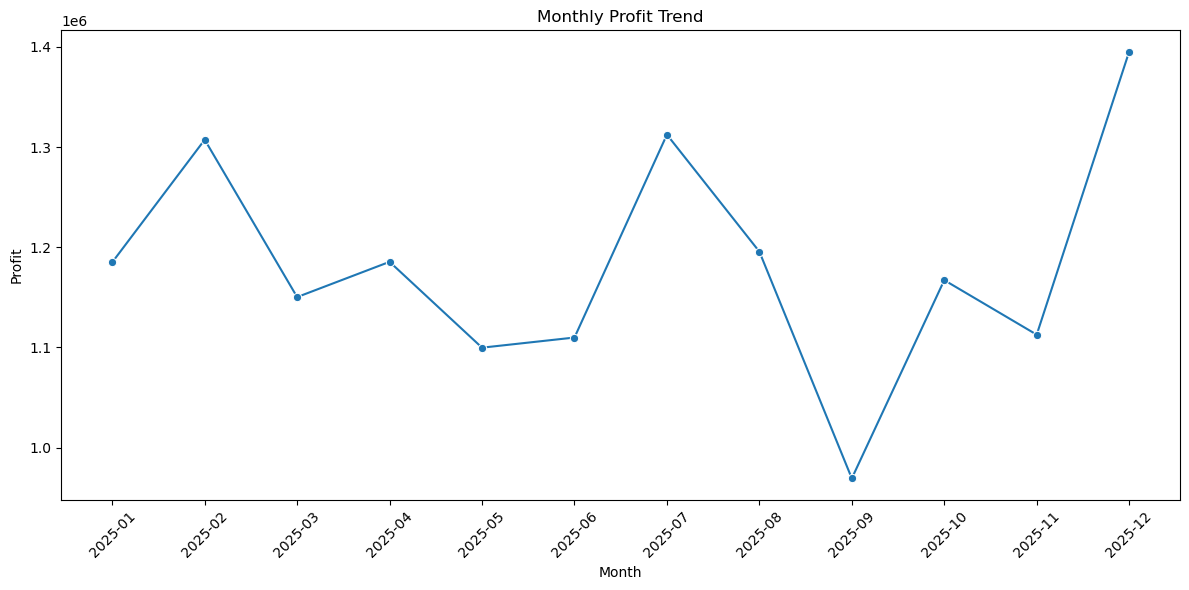

In [134]:
monthly_profit = (
    df_clean.groupby("month", as_index=False)["profit"]
    .sum()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_profit,
    x="month",
    y="profit",
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [135]:
best_profit_month = monthly_profit.loc[
    monthly_profit["profit"].idxmax()
]

best_profit_month

month       2025-12
profit    1395245.0
Name: 11, dtype: object

In [136]:
category_analysis = (
    df_clean.groupby("category")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        quantity_sold=("quantity", "sum")
    )
    .reset_index()
)

category_analysis["profit_margin"] = (
    category_analysis["total_profit"] /
    category_analysis["total_sales"]
) * 100

category_analysis.sort_values(
    "total_sales",
    ascending=False
)

,category,total_sales,total_profit,quantity_sold,profit_margin
1,Electronics,45793350.0,7449350.0,2262,16.267318
3,Furniture,9159225.0,1961625.0,1093,21.416932
4,Home Appliances,5528315.0,1596115.0,1103,28.871636
2,Fashion,3026170.0,1087670.0,1391,35.942131
6,Sports,2784810.0,973560.0,1197,34.959656
5,Home Decor,1561350.0,648000.0,1176,41.502546
0,Accessories,858000.0,334800.0,436,39.020979
7,Stationery,271975.0,138875.0,605,51.061678


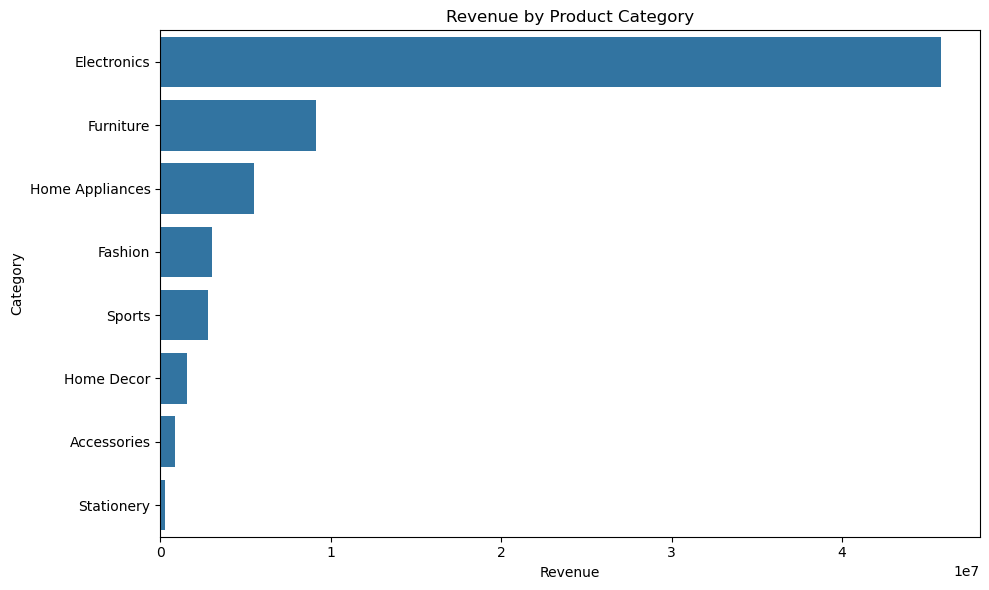

In [137]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_analysis.sort_values(
        "total_sales",
        ascending=False
    ),
    x="total_sales",
    y="category"
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

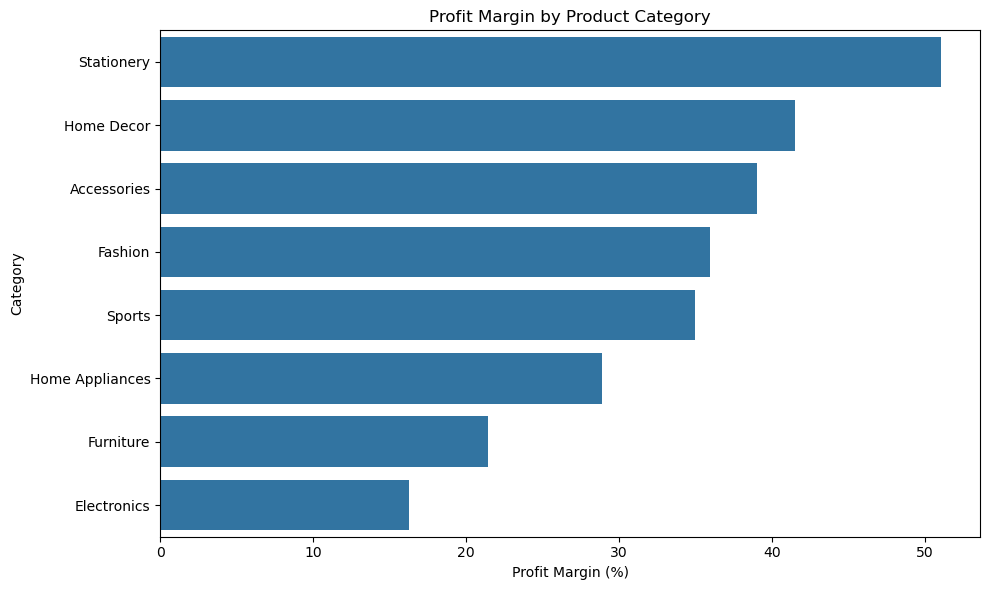

In [138]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_analysis.sort_values(
        "profit_margin",
        ascending=False
    ),
    x="profit_margin",
    y="category"
)

plt.title("Profit Margin by Product Category")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [139]:
top_products = (
    df_clean.groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_name
Laptop           25960000.0
Smartphone       15827000.0
Desk              4250400.0
Office Chair      3088475.0
Smart Watch       2496975.0
Air Fryer         2300625.0
Running Shoes     2040750.0
Bookshelf         1820350.0
Coffee Maker      1656050.0
Mixer Grinder     1571640.0
Name: sales, dtype: float64

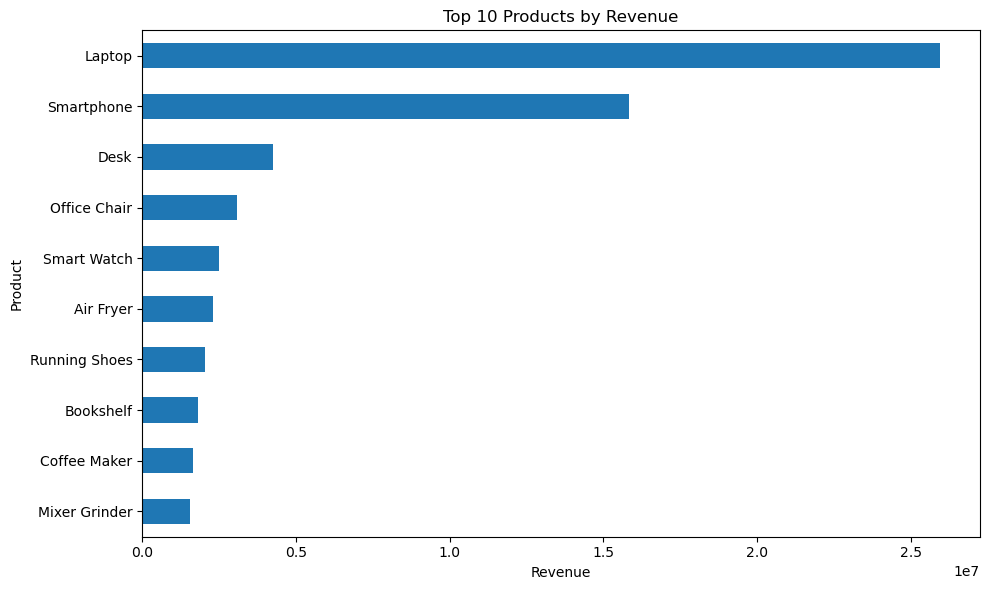

In [140]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [141]:
regional_analysis = (
    df_clean.groupby("region")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

regional_analysis

,region,total_sales,total_profit,orders
0,East,11906445.0,2437805.0,853
1,North,16133660.0,3297030.0,1204
2,South,23395825.0,4877725.0,1687
3,West,17547265.0,3577435.0,1256


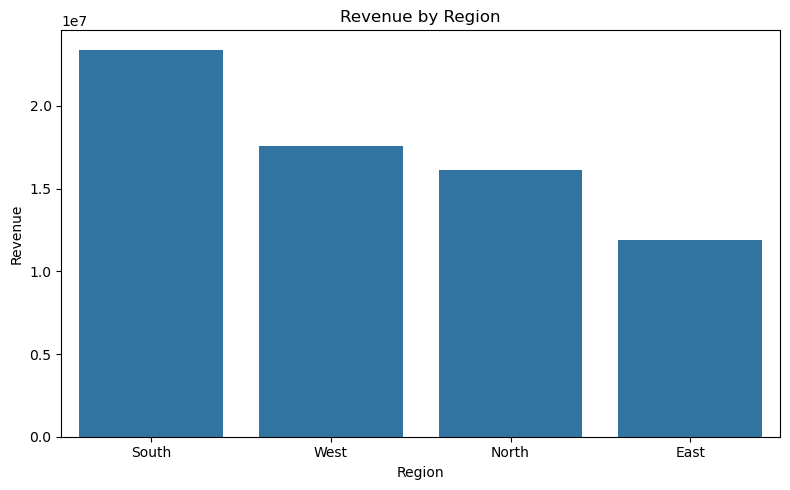

In [142]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=regional_analysis.sort_values(
        "total_sales",
        ascending=False
    ),
    x="region",
    y="total_sales"
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [143]:
discount_analysis = (
    df_clean.groupby("discount")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

discount_analysis["discount_percentage"] = (
    discount_analysis["discount"] * 100
)

discount_analysis["profit_margin"] = (
    discount_analysis["total_profit"] /
    discount_analysis["total_sales"]
) * 100

discount_analysis

,discount,total_sales,total_profit,orders,discount_percentage,profit_margin
0,0.00,9291960.0,2663510.0,599,0.0,28.664674
1,0.05,15630255.0,3919275.0,1073,5.0,25.074927
2,0.10,22298490.0,4630490.0,1517,10.0,20.765935
3,0.15,12762920.0,2130450.0,1022,15.0,16.692497
4,0.20,6119120.0,702400.0,527,20.0,11.478775
5,0.25,2880450.0,143870.0,262,25.0,4.994706


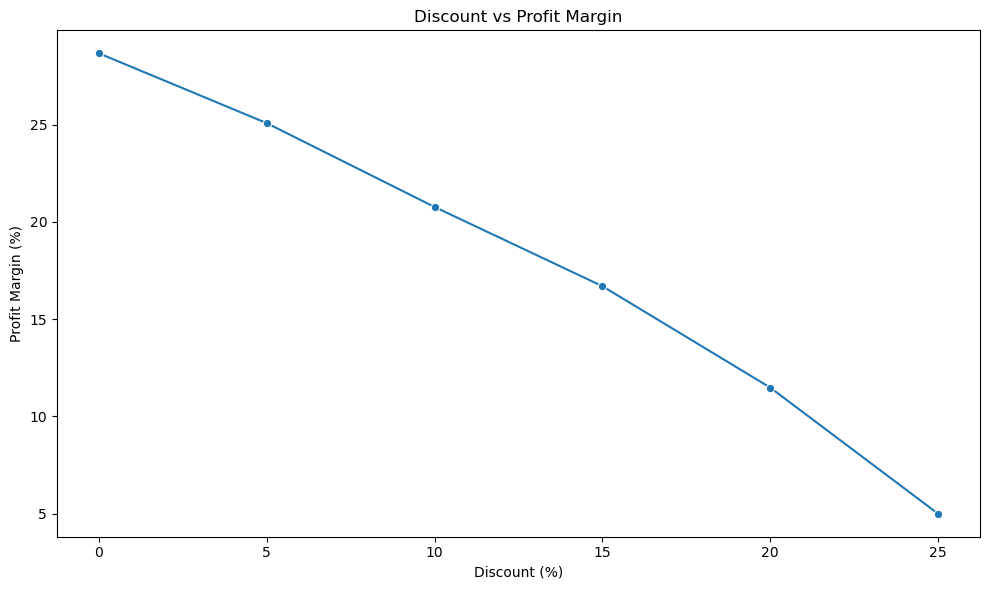

In [144]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=discount_analysis,
    x="discount_percentage",
    y="profit_margin",
    marker="o"
)

plt.title("Discount vs Profit Margin")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

In [145]:
customer_analysis = (
    df_clean.groupby(
        ["customer_id", "customer_name"]
    )
    .agg(
        total_orders=("order_id", "nunique"),
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum")
    )
    .reset_index()
)

customer_analysis.head()

,customer_id,customer_name,total_orders,total_sales,total_profit
0,C0001,Rohan Mehta,9,146740.0,26240.0
1,C0002,Raj Iyer,6,120425.0,27565.0
2,C0003,Neha Nair,7,136230.0,16390.0
3,C0004,Rohan Shah,5,44580.0,10550.0
4,C0005,Varun Joshi,4,119740.0,16640.0


In [146]:
top_customers = customer_analysis.sort_values(
    "total_sales",
    ascending=False
).head(10)

top_customers

,customer_id,customer_name,total_orders,total_sales,total_profit
184,C0183,Kavya Gupta,8,531055.0,97135.0
146,C0146,Simran Iyer,9,473920.0,77700.0
868,C0872,Nikhil Shah,5,431000.0,69000.0
221,C0220,Varun Sharma,10,416215.0,74315.0
183,C0182,Meera Desai,14,413615.0,99675.0
12,C0013,Sneha Desai,13,377220.0,66870.0
90,C0090,Simran Nair,10,361020.0,85530.0
634,C0633,Nikhil Patel,4,350500.0,52300.0
549,C0547,Rohan Verma,9,324110.0,45810.0
895,C0900,Arjun Sharma,5,305000.0,49660.0


In [147]:
repeat_customers = (
    customer_analysis["total_orders"] > 1
).sum()

one_time_customers = (
    customer_analysis["total_orders"] == 1
).sum()

total_customers = len(customer_analysis)

repeat_customer_percentage = (
    repeat_customers / total_customers
) * 100

print("Total Customers:", total_customers)
print("Repeat Customers:", repeat_customers)
print("One-Time Customers:", one_time_customers)
print(
    "Repeat Customer Percentage:",
    round(repeat_customer_percentage, 2),
    "%"
)

Total Customers: 995
Repeat Customers: 925
One-Time Customers: 70
Repeat Customer Percentage: 92.96 %


In [148]:
customer_analysis["customer_segment"] = np.select(
    [
        customer_analysis["total_sales"] >= 100000,
        customer_analysis["total_sales"] >= 50000
    ],
    [
        "High Value",
        "Medium Value"
    ],
    default="Low Value"
)

In [149]:
customer_analysis["customer_segment"].value_counts()

customer_segment
Low Value       510
Medium Value    244
High Value      241
Name: count, dtype: int64

In [150]:
customer_segment_analysis = (
    customer_analysis
    .groupby("customer_segment")
    .agg(
        customer_count=("customer_id", "count"),
        total_revenue=("total_sales", "sum")
    )
    .reset_index()
)

customer_segment_analysis

,customer_segment,customer_count,total_revenue
0,High Value,241,40534960.0
1,Low Value,510,11340465.0
2,Medium Value,244,17107770.0


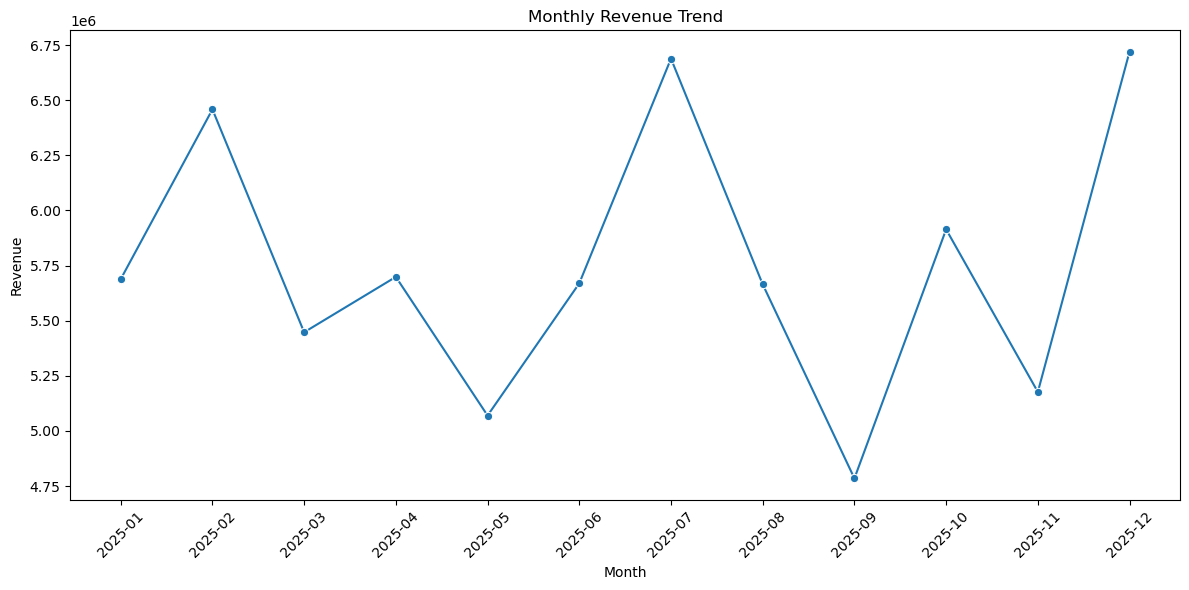

<class 'FileNotFoundError'>: [Errno 44] No such file or directory: '../visualizations/monthly_revenue.png'

In [152]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="sales",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../visualizations/monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Key Business Insights

### Sales Performance

- Identify the highest revenue month.
- Identify the lowest revenue month.
- Analyze the overall monthly sales trend.

### Product Performance

- Identify the top revenue-generating products.
- Identify the most profitable products.
- Identify high-revenue products with low profit margins.

### Customer Analysis

- Identify the top customers by revenue.
- Calculate the percentage of repeat customers.

### Regional Performance

- Identify the strongest-performing region.
- Compare regional sales and profitability.

### Discount Analysis

- Analyze whether higher discounts are associated with lower profitability.

In [154]:
print("Total Revenue:", round(total_revenue, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(average_order_value, 2))
print("Profit Margin:", round(profit_margin, 2))

print("\nBest Sales Month:")
print(best_sales_month)

print("\nBest Profit Month:")
print(best_profit_month)

print("\nRepeat Customer Percentage:",
      round(repeat_customer_percentage, 2), "%")

Total Revenue: 68983195.0
Total Profit: 14189995.0
Total Orders: 5000
Total Customers: 995
Average Order Value: 13796.64
Profit Margin: 20.57

Best Sales Month:
month      2025-12
sales    6720285.0
Name: 11, dtype: object

Best Profit Month:
month       2025-12
profit    1395245.0
Name: 11, dtype: object

Repeat Customer Percentage: 92.96 %


In [155]:
print("\nTop Categories:")
print(
    category_analysis.sort_values(
        "total_sales",
        ascending=False
    ).head()
)

print("\nTop Products:")
print(top_products)

print("\nRegional Performance:")
print(
    regional_analysis.sort_values(
        "total_sales",
        ascending=False
    )
)

print("\nDiscount Analysis:")
print(discount_analysis)


Top Categories:
          category  total_sales  total_profit  quantity_sold  profit_margin
1      Electronics   45793350.0     7449350.0           2262      16.267318
3        Furniture    9159225.0     1961625.0           1093      21.416932
4  Home Appliances    5528315.0     1596115.0           1103      28.871636
2          Fashion    3026170.0     1087670.0           1391      35.942131
6           Sports    2784810.0      973560.0           1197      34.959656

Top Products:
product_name
Laptop           25960000.0
Smartphone       15827000.0
Desk              4250400.0
Office Chair      3088475.0
Smart Watch       2496975.0
Air Fryer         2300625.0
Running Shoes     2040750.0
Bookshelf         1820350.0
Coffee Maker      1656050.0
Mixer Grinder     1571640.0
Name: sales, dtype: float64

Regional Performance:
  region  total_sales  total_profit  orders
2  South   23395825.0     4877725.0    1687
3   West   17547265.0     3577435.0    1256
1  North   16133660.0     3297030.0 